In [2]:
import numpy as np
import scipy as sc

import wfdb
# wfdb has a own method for signal resampling.
from wfdb import processing

import pathlib as pl

import matplotlib.pyplot as plt

import sys
sys.path.append('.')
sys.path.append('../')
from classifier.driver import load_challenge_data

## Sampling Rate
A first glimpse on the sampling rate (257 Hz. Strange --> See https://physionet.org/content/incartdb/1.0.0/)

In [3]:
# Explore the dataset: What sampling rates do we have
rates = []
for file in pl.Path('../utils/temp/').iterdir():
    if file.name.split('.')[-1] == 'hea':
        # Open file an check sampling rate
        with open(file) as f:
            head = f.read().split('\n')[0].split(' ')[2]
        rates.append(int(head))

In [4]:
# We have 3 sampling rates, where 500 Hz is the most prominent one
display(np.unique(rates, return_counts=True))

# Selecting 500 Hz as temporary (most prominent) sampling frequency for our dataset 
target_sampling_rate = 500

(array([ 257,  500, 1000]), array([   74, 42511,   516]))

In [5]:
# Check out an example with a sampling_rate lower than our target sampling rate
for file in pl.Path('../utils/temp/').iterdir():
    if file.name.split('.')[-1] == 'hea':
        # Open file an check sampling rate
        with open(file) as f:
            original_frequency = np.float64(f.read().split('\n')[0].split(' ')[2])
        if int(original_frequency) < target_sampling_rate:

            
            # Loading the original data from the *.mat file
            example = str(pl.Path('../utils/temp/').joinpath(file.name.replace('.hea', '.mat')))
            y_original, _ = load_challenge_data(example)
            t_original = np.linspace(0, 1./257. * y_original.shape[1], y_original.shape[1])

            upsampling_factor = np.float(target_sampling_rate/original_frequency)
            upsampling_length = y_original.shape[1] * upsampling_factor

            # Using scipys fouier based method for upsampling
            new_length = int(y_original.shape[1] * upsampling_factor)
            y_upsampled = np.empty((y_original.shape[0], new_length), dtype=y_original.dtype)
            for i_lead in range(0, y_original.shape[0]):
                y_upsampled[i_lead, :] = sc.signal.resample(y_original[i_lead, :], new_length)
            
            t_upsampled = np.linspace(0, 1./500. * y_upsampled.shape[1], y_upsampled.shape[1])
            
            # Using wfdbs original method for upsampling
            y_wfdb = np.empty((y_original.shape[0], new_length), dtype=y_original.dtype)
            for i_lead in range(0, y_original.shape[0]):
                y_wfdb_l, x_wfdb = wfdb.processing.resample_sig(y_original[i_lead, :],
                                                                  original_frequency, target_sampling_rate)
                y_wfdb[i_lead] = y_wfdb_l
            t_wfdb = 1./original_frequency * x_wfdb
            
            break

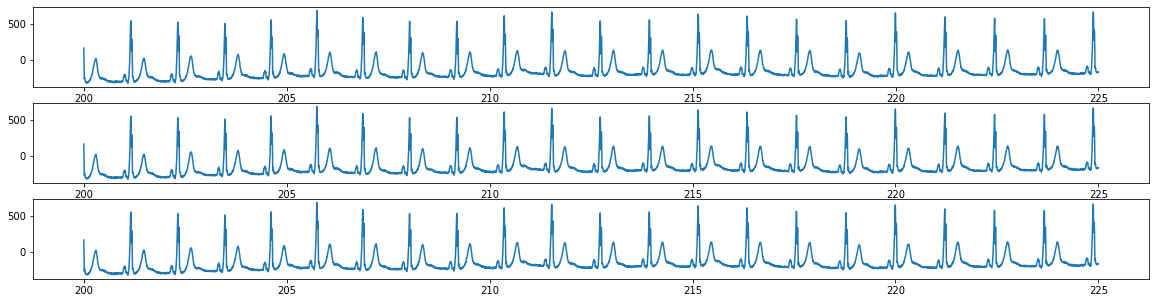

In [6]:
fig = plt.figure(figsize=(20, 5))
ax = fig.add_subplot(311)
ax.plot(t_original[(200. <= t_original) & (t_original <= 225.)],
        y_original[2, :][(200. <= t_original) & (t_original <= 225.)])
ax = fig.add_subplot(312)
ax.plot(t_upsampled[(200. <= t_upsampled) & (t_upsampled <= 225.)],
        y_upsampled[2, :][(200. <= t_upsampled) & (t_upsampled <= 225.)])
ax = fig.add_subplot(313)
ax.plot(t_wfdb[(200. <= t_wfdb) & (t_wfdb <= 225.)],
        y_wfdb[2, :][(200. <= t_wfdb) & (t_wfdb <= 225.)])

plt.show()

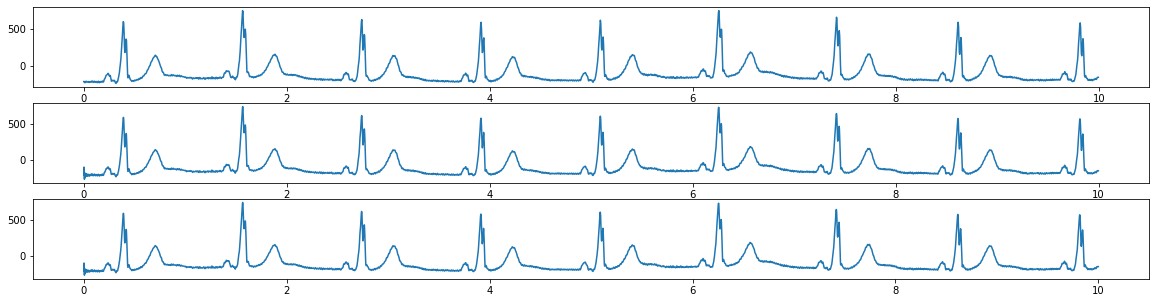

In [7]:
fig = plt.figure(figsize=(20, 5))
ax = fig.add_subplot(311)
ax.plot(t_original[(t_original <= 10.)],
        y_original[2, :][(t_original <= 10.)])
ax = fig.add_subplot(312)
ax.plot(t_upsampled[(t_upsampled <= 10.)],
        y_upsampled[2, :][ (t_upsampled <= 10.)])
ax = fig.add_subplot(313)
ax.plot(t_wfdb[(t_wfdb <= 10.)],
        y_wfdb[2, :][(t_wfdb <= 10.)])

plt.show()

In [8]:
# Note: At the beginning and the end the Fouier upsampling method fails (artifacts) 
# --> Do we even care? Is it part of the attr file? See annotation files?

In [24]:
# Creating a function to include into the project

def resample(data, source_fs, target_fs):
    """ Resample input ecg with source frequency to target frequency using Fourier method along the given axis t.
    
    Args:
        data (numpy array): 12 lead ecg with dimensions leads X time.
        source_fs: The sampling frequency of the source signal
        target_fs: The sampling frequency of the target signal
    
    Example:
        resampled_data = resample(np.empty((12, 10000), dtype=np.float64), 250, 500)
        >> resapmled_data.shape != (12, 20000)
    """
    upsampling_factor = np.float(target_fs/source_fs)

    out_length = int(data.shape[1] * upsampling_factor)
    out_data = np.empty((data.shape[0], out_length), dtype=data.dtype)
    
    for i_lead in range(0, data.shape[0]):
        out_data[i_lead, :] = sc.signal.resample(data[i_lead, :], out_length)
            
    return out_data

In [25]:
# Test the function
target_frequency = 500

for file in pl.Path('../utils/temp/').iterdir():
    if file.name.split('.')[-1] == 'hea':
        # Open file an check sampling rate
        with open(file) as f:
            original_frequency = np.float64(f.read().split('\n')[0].split(' ')[2])

        if int(original_frequency) != int(target_sampling_rate):
            input_data, _ = load_challenge_data(
                str(pl.Path('../utils/temp/').joinpath(file.name.replace('.hea', '.mat'))))

            output_data = resample(input_data, original_frequency, target_frequency)
            
            print("Resampled from:", original_frequency, "Hz to:", target_frequency, "Hz with input shape",
                 input_data.shape, "to output shape:", output_data.shape)



Resampled from: 1000.0 Hz to: 500 Hz with input shape (12, 115200) to output shape: (12, 57600)
Resampled from: 1000.0 Hz to: 500 Hz with input shape (12, 115200) to output shape: (12, 57600)
Resampled from: 1000.0 Hz to: 500 Hz with input shape (12, 115200) to output shape: (12, 57600)
Resampled from: 1000.0 Hz to: 500 Hz with input shape (12, 115200) to output shape: (12, 57600)
Resampled from: 1000.0 Hz to: 500 Hz with input shape (12, 115200) to output shape: (12, 57600)
Resampled from: 1000.0 Hz to: 500 Hz with input shape (12, 115200) to output shape: (12, 57600)
Resampled from: 1000.0 Hz to: 500 Hz with input shape (12, 115200) to output shape: (12, 57600)
Resampled from: 1000.0 Hz to: 500 Hz with input shape (12, 115200) to output shape: (12, 57600)
Resampled from: 1000.0 Hz to: 500 Hz with input shape (12, 120012) to output shape: (12, 60006)
Resampled from: 1000.0 Hz to: 500 Hz with input shape (12, 115200) to output shape: (12, 57600)
Resampled from: 1000.0 Hz to: 500 Hz wit

Resampled from: 1000.0 Hz to: 500 Hz with input shape (12, 115200) to output shape: (12, 57600)
Resampled from: 257.0 Hz to: 500 Hz with input shape (12, 462600) to output shape: (12, 900000)
Resampled from: 1000.0 Hz to: 500 Hz with input shape (12, 115200) to output shape: (12, 57600)
Resampled from: 257.0 Hz to: 500 Hz with input shape (12, 462600) to output shape: (12, 900000)
Resampled from: 1000.0 Hz to: 500 Hz with input shape (12, 115200) to output shape: (12, 57600)
Resampled from: 1000.0 Hz to: 500 Hz with input shape (12, 32000) to output shape: (12, 16000)
Resampled from: 1000.0 Hz to: 500 Hz with input shape (12, 115200) to output shape: (12, 57600)
Resampled from: 1000.0 Hz to: 500 Hz with input shape (12, 115200) to output shape: (12, 57600)
Resampled from: 1000.0 Hz to: 500 Hz with input shape (12, 115200) to output shape: (12, 57600)
Resampled from: 1000.0 Hz to: 500 Hz with input shape (12, 120012) to output shape: (12, 60006)
Resampled from: 1000.0 Hz to: 500 Hz with

Resampled from: 1000.0 Hz to: 500 Hz with input shape (12, 115200) to output shape: (12, 57600)
Resampled from: 1000.0 Hz to: 500 Hz with input shape (12, 115200) to output shape: (12, 57600)
Resampled from: 1000.0 Hz to: 500 Hz with input shape (12, 120012) to output shape: (12, 60006)
Resampled from: 1000.0 Hz to: 500 Hz with input shape (12, 120012) to output shape: (12, 60006)
Resampled from: 1000.0 Hz to: 500 Hz with input shape (12, 120012) to output shape: (12, 60006)
Resampled from: 1000.0 Hz to: 500 Hz with input shape (12, 115200) to output shape: (12, 57600)
Resampled from: 1000.0 Hz to: 500 Hz with input shape (12, 38400) to output shape: (12, 19200)
Resampled from: 1000.0 Hz to: 500 Hz with input shape (12, 120012) to output shape: (12, 60006)
Resampled from: 1000.0 Hz to: 500 Hz with input shape (12, 120012) to output shape: (12, 60006)
Resampled from: 1000.0 Hz to: 500 Hz with input shape (12, 115200) to output shape: (12, 57600)
Resampled from: 1000.0 Hz to: 500 Hz with

Resampled from: 1000.0 Hz to: 500 Hz with input shape (12, 115200) to output shape: (12, 57600)
Resampled from: 1000.0 Hz to: 500 Hz with input shape (12, 115200) to output shape: (12, 57600)
Resampled from: 1000.0 Hz to: 500 Hz with input shape (12, 115200) to output shape: (12, 57600)
Resampled from: 1000.0 Hz to: 500 Hz with input shape (12, 115200) to output shape: (12, 57600)
Resampled from: 1000.0 Hz to: 500 Hz with input shape (12, 120012) to output shape: (12, 60006)
Resampled from: 1000.0 Hz to: 500 Hz with input shape (12, 120012) to output shape: (12, 60006)
Resampled from: 1000.0 Hz to: 500 Hz with input shape (12, 32000) to output shape: (12, 16000)
Resampled from: 1000.0 Hz to: 500 Hz with input shape (12, 38400) to output shape: (12, 19200)
Resampled from: 1000.0 Hz to: 500 Hz with input shape (12, 120012) to output shape: (12, 60006)
Resampled from: 1000.0 Hz to: 500 Hz with input shape (12, 120012) to output shape: (12, 60006)
Resampled from: 1000.0 Hz to: 500 Hz with 

Resampled from: 1000.0 Hz to: 500 Hz with input shape (12, 120012) to output shape: (12, 60006)
Resampled from: 1000.0 Hz to: 500 Hz with input shape (12, 120012) to output shape: (12, 60006)
Resampled from: 1000.0 Hz to: 500 Hz with input shape (12, 115200) to output shape: (12, 57600)
Resampled from: 1000.0 Hz to: 500 Hz with input shape (12, 115200) to output shape: (12, 57600)
Resampled from: 1000.0 Hz to: 500 Hz with input shape (12, 120012) to output shape: (12, 60006)
Resampled from: 1000.0 Hz to: 500 Hz with input shape (12, 120012) to output shape: (12, 60006)
Resampled from: 1000.0 Hz to: 500 Hz with input shape (12, 115200) to output shape: (12, 57600)
Resampled from: 1000.0 Hz to: 500 Hz with input shape (12, 115200) to output shape: (12, 57600)
Resampled from: 1000.0 Hz to: 500 Hz with input shape (12, 115200) to output shape: (12, 57600)
Resampled from: 1000.0 Hz to: 500 Hz with input shape (12, 115200) to output shape: (12, 57600)
Resampled from: 1000.0 Hz to: 500 Hz wit

Resampled from: 1000.0 Hz to: 500 Hz with input shape (12, 120012) to output shape: (12, 60006)
Resampled from: 1000.0 Hz to: 500 Hz with input shape (12, 120012) to output shape: (12, 60006)
Resampled from: 1000.0 Hz to: 500 Hz with input shape (12, 115200) to output shape: (12, 57600)
Resampled from: 1000.0 Hz to: 500 Hz with input shape (12, 115200) to output shape: (12, 57600)
Resampled from: 1000.0 Hz to: 500 Hz with input shape (12, 120012) to output shape: (12, 60006)
Resampled from: 1000.0 Hz to: 500 Hz with input shape (12, 120012) to output shape: (12, 60006)
Resampled from: 1000.0 Hz to: 500 Hz with input shape (12, 115200) to output shape: (12, 57600)
Resampled from: 1000.0 Hz to: 500 Hz with input shape (12, 115200) to output shape: (12, 57600)
Resampled from: 1000.0 Hz to: 500 Hz with input shape (12, 115200) to output shape: (12, 57600)
Resampled from: 257.0 Hz to: 500 Hz with input shape (12, 462600) to output shape: (12, 900000)
Resampled from: 1000.0 Hz to: 500 Hz wit

Resampled from: 1000.0 Hz to: 500 Hz with input shape (12, 115200) to output shape: (12, 57600)
Resampled from: 1000.0 Hz to: 500 Hz with input shape (12, 115200) to output shape: (12, 57600)
Resampled from: 1000.0 Hz to: 500 Hz with input shape (12, 115200) to output shape: (12, 57600)
Resampled from: 1000.0 Hz to: 500 Hz with input shape (12, 115200) to output shape: (12, 57600)
Resampled from: 1000.0 Hz to: 500 Hz with input shape (12, 115200) to output shape: (12, 57600)
Resampled from: 1000.0 Hz to: 500 Hz with input shape (12, 38400) to output shape: (12, 19200)
Resampled from: 1000.0 Hz to: 500 Hz with input shape (12, 115200) to output shape: (12, 57600)
Resampled from: 1000.0 Hz to: 500 Hz with input shape (12, 38400) to output shape: (12, 19200)
Resampled from: 1000.0 Hz to: 500 Hz with input shape (12, 115200) to output shape: (12, 57600)
Resampled from: 1000.0 Hz to: 500 Hz with input shape (12, 115200) to output shape: (12, 57600)
Resampled from: 1000.0 Hz to: 500 Hz with 